In [14]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [58]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 50
CHANNELS = 3

In [24]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 2152 files belonging to 3 classes.


In [25]:
class_names = dataset.class_names
class_names
len(dataset)

68

In [26]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    # print(label_batch.numpy())

(32, 256, 256, 3)
[0 0 0 0 0 1 1 1 0 1 2 1 1 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1]


In [30]:
# Printing the first image of 32 images
for image_batch, label_batch in dataset.take(1):
    print(image_batch[31])

tf.Tensor(
[[[ 67.  63.  78.]
  [109. 105. 120.]
  [100.  96. 111.]
  ...
  [157. 158. 176.]
  [158. 159. 177.]
  [158. 159. 177.]]

 [[100.  96. 111.]
  [134. 130. 145.]
  [138. 134. 149.]
  ...
  [157. 158. 176.]
  [157. 158. 176.]
  [155. 156. 174.]]

 [[110. 106. 121.]
  [111. 107. 122.]
  [100.  96. 111.]
  ...
  [156. 157. 175.]
  [153. 154. 172.]
  [148. 149. 167.]]

 ...

 [[ 90.  86. 100.]
  [124. 120. 134.]
  [106. 102. 116.]
  ...
  [147. 150. 167.]
  [145. 148. 165.]
  [142. 145. 162.]]

 [[118. 114. 128.]
  [126. 122. 136.]
  [ 78.  74.  88.]
  ...
  [138. 141. 158.]
  [136. 139. 156.]
  [135. 138. 155.]]

 [[ 91.  87. 101.]
  [128. 124. 138.]
  [ 95.  91. 105.]
  ...
  [138. 141. 158.]
  [135. 138. 155.]
  [135. 138. 155.]]], shape=(256, 256, 3), dtype=float32)


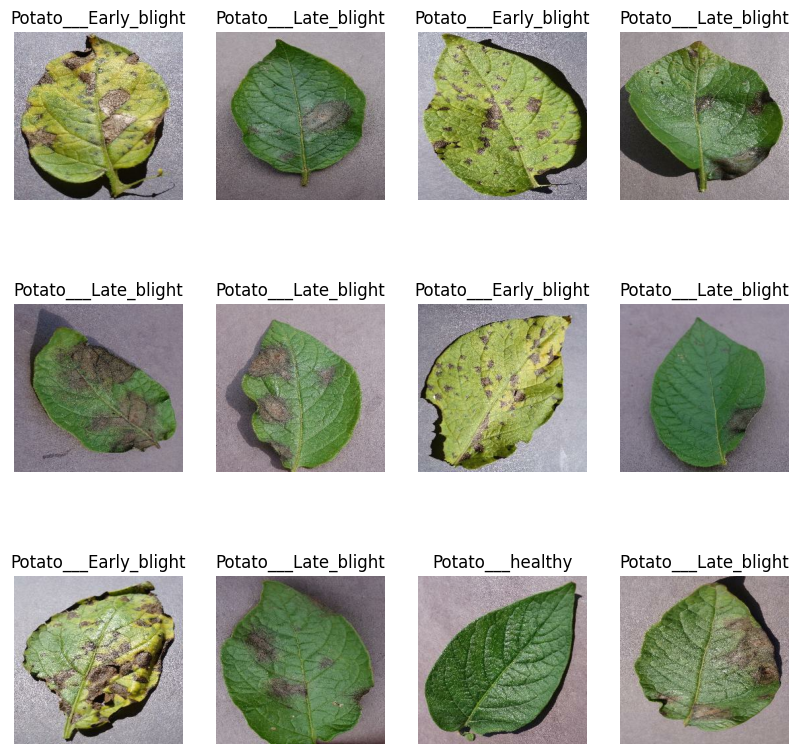

In [39]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [40]:
len(dataset)

68

In [42]:
# 80% ==> Training data
# 20% ==> 10% validation, 10% testing


In [47]:
def get_dataset_partitions_tf(ds, train_split=0.8,val_split=0.1, test_split=0.1, shuffle=True, shuffle_size = 10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds
    

In [48]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [49]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [53]:
# preprocessing pipeline
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1.0/255)
])

In [55]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


In [56]:
print("OK")

OK


In [62]:
# Define input_shape for a single image
input_shape_single = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

n_classes = 3

model = models.Sequential([
    
    # Input Layer
    layers.Input(shape=input_shape_single),

    resize_and_rescale,
    data_augmentation,

    # CNN Layer 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 3
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(n_classes, activation='softmax')
])

# Build model


# Model summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_3 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │       3,686,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,742,979 (14.28 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [64]:
history = model.fit(train_ds, epochs=EPOCHS,batch_size = BATCH_SIZE, verbose=1,validation_data=val_ds)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 728ms/step - accuracy: 0.6881 - loss: 0.8307 - val_accuracy: 0.7344 - val_loss: 0.7302
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 733ms/step - accuracy: 0.8299 - loss: 0.4464 - val_accuracy: 0.7188 - val_loss: 0.5037
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 760ms/step - accuracy: 0.8814 - loss: 0.3100 - val_accuracy: 0.8594 - val_loss: 0.3306
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 876ms/step - accuracy: 0.8941 - loss: 0.2767 - val_accuracy: 0.8958 - val_loss: 0.3335
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 837ms/step - accuracy: 0.9172 - loss: 0.2390 - val_accuracy: 0.8229 - val_loss: 0.5478
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 839ms/step - accuracy: 0.9282 - loss: 0.2020 - val_accuracy: 0.8802 - val_loss: 0.2109
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 784ms/step - accuracy: 0.9450 - loss: 0.1572 - val_accuracy: 0.8854 - val_loss: 0.2273
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 792ms/step - accuracy: 0.9554 - loss: 0.1091 - val_accu

In [65]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9727 - loss: 0.0518


In [66]:
scores


[0.05182516574859619, 0.97265625]

In [67]:
history


In [68]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [69]:
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and validation Accuracy')

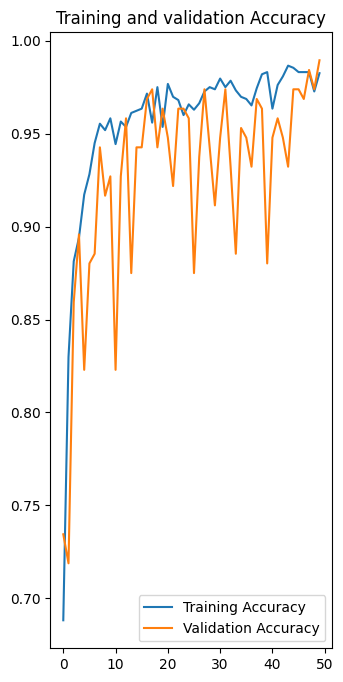

In [70]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and validation Accuracy')

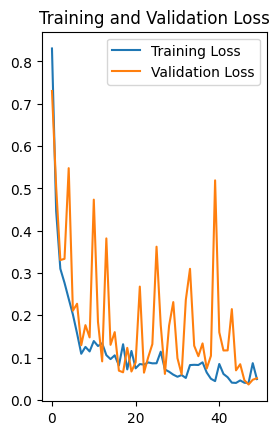

In [72]:
plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
first images's actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
[9.9999988e-01 1.5658061e-07 9.0845858e-34]
0
Predicted Label: Potato___Early_blight


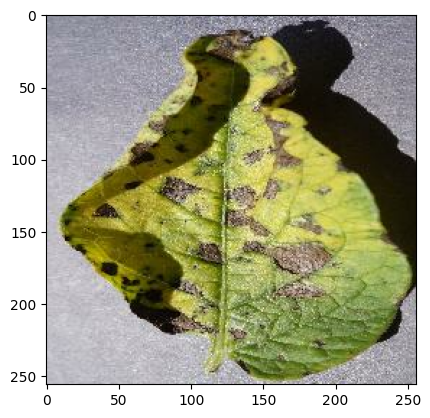

In [84]:
import numpy as np
for image_batch, labels_batch in test_ds.take(1):
    plt.imshow(image_batch[0].numpy().astype('uint8'))
    first_image =image_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    print("first image to predict")
    plt.imshow(first_image)
    print("first images's actual label:", class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print(batch_prediction[0])
    print(np.argmax(batch_prediction[0]))
    print("Predicted Label:", class_names[np.argmax(batch_prediction[0])])

In [93]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array,0) # this will create a batch
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100* (np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


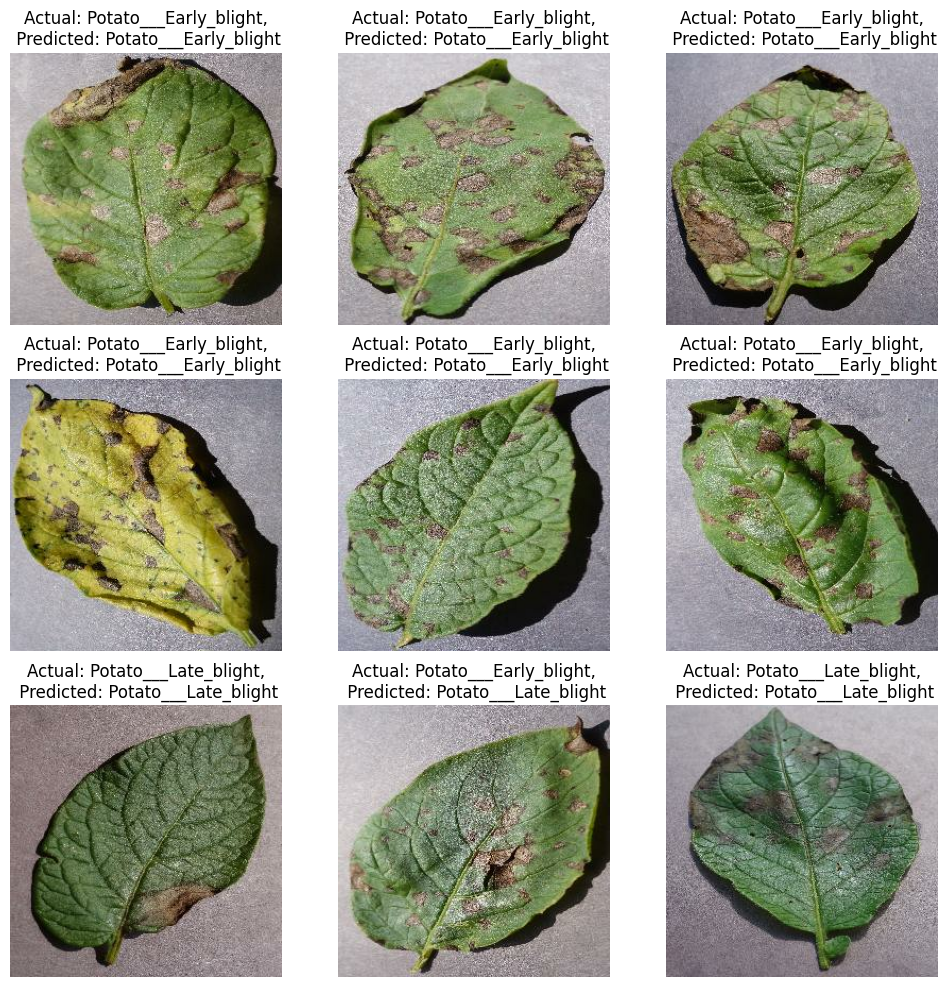

In [95]:
plt.figure(figsize=(12,12))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}")
        plt.axis("off")

In [99]:
model_version = 1
model.save(f"./models/model_v{model_version}.keras")